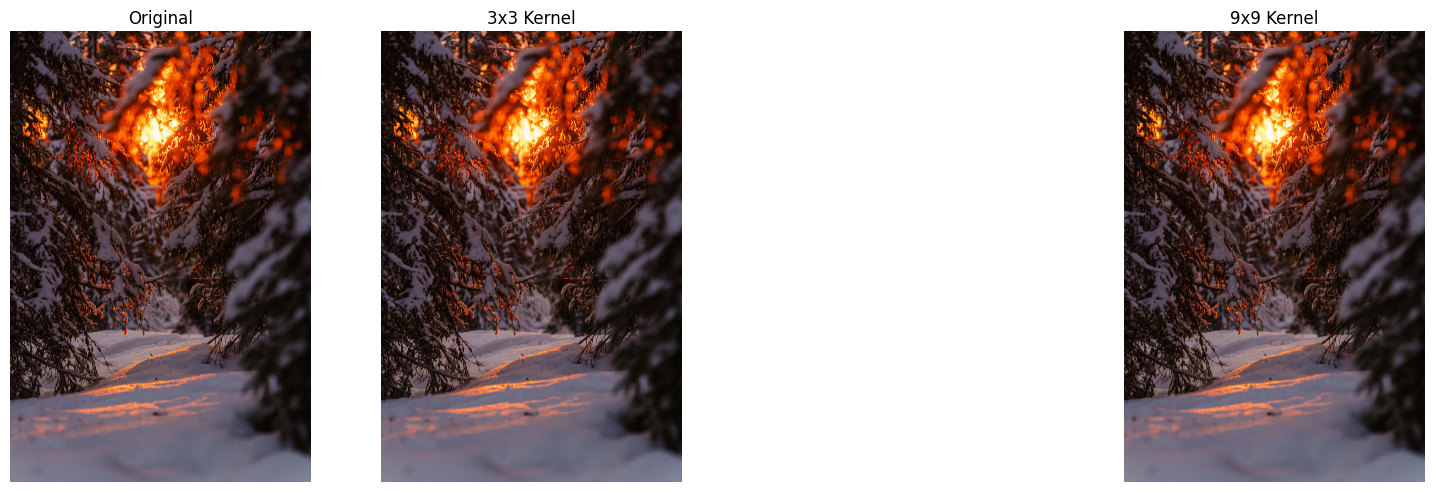

In [ ]:
import cv2
import matplotlib.pyplot as plt
image = cv2.imread("image_test1.jpg")

if image is None:
    print("Error: Could not load image. Please ensure 'image.jpg' is in the current directory or provide the correct path.")
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    blur_3 = cv2.blur(image, (3, 3))шь
    blur_5 = cv2.blur(image, (5, 5))
    blur_9 = cv2.blur(image, (9, 9))

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2,)
    plt.imshow(blur_3)
    plt.title("3x3 Kernel")
    plt.axis("off")
    plt.subplot(1, 4, 4)
    plt.imshow(blur_9)
    plt.title("9x9 Kernel")
    plt.axis("off")

    plt.tight_layout()
    plt.show()



In [ ]:
from google.colab import files
uploaded = files.upload()

# Challenge 2

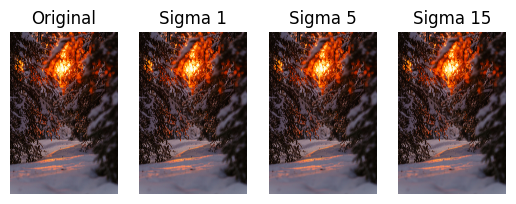

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image_test1.jpg") # Changed 'image.jpg' to 'image_test1.jpg'

if img is None:
    print("Error: Could not load image. Please ensure 'image_test1.jpg' is in the current directory or provide the correct path.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    k = (15, 15)

    g1 = cv2.GaussianBlur(img, k, 1)
    g5 = cv2.GaussianBlur(img, k, 5)
    g15 = cv2.GaussianBlur(img, k, 15)

    plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(g1)
    plt.title("Sigma 1")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(g5)
    plt.title("Sigma 5")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(g15)
    plt.title("Sigma 15")
    plt.axis("off")

    plt.show()

# Challenge 3

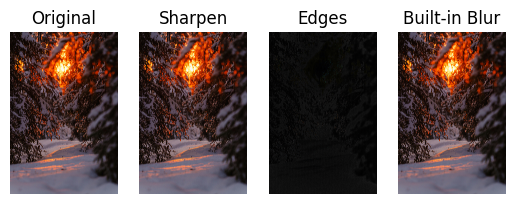

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image_test1.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

sharpen = np.array([[ 0, -1,  0],
                    [-1,  5, -1],
                    [ 0, -1,  0]])

edge = np.array([[-1, -1, -1],
                 [-1,  8, -1],
                 [-1, -1, -1]])
sharp_img = cv2.filter2D (img, -1, sharpen)
edge_img = cv2.filter2D (img,-1, edge)
blur = cv2.blur(img, (3,3))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(sharp_img)
plt.title("Sharpen")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(edge_img)
plt.title("Edges")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(blur)
plt.title("Built-in Blur")
plt.axis("off")

plt.show()



# Challenge 4

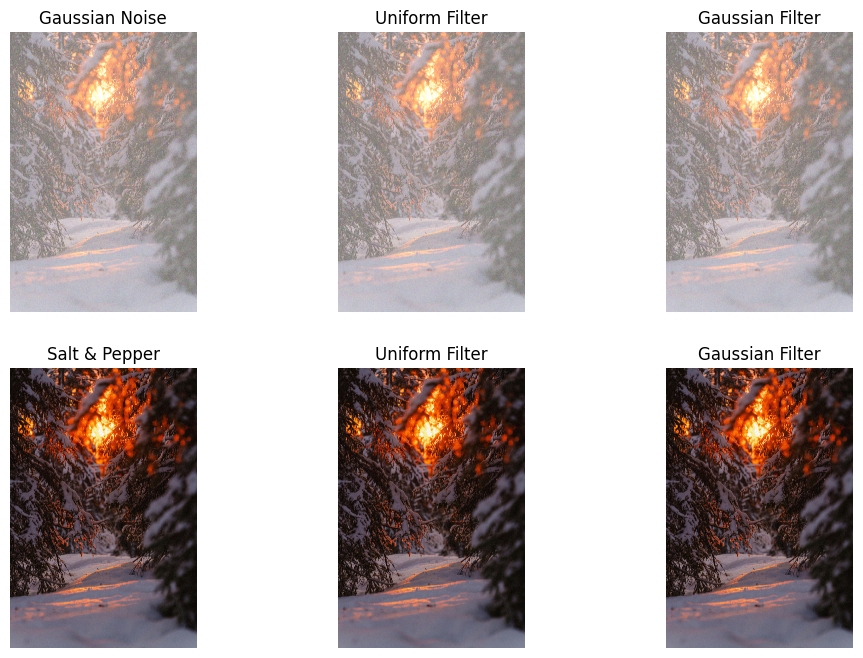

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image_test1.jpg") # Changed from 'image.jpg' to 'image_test1.jpg'

if img is None:
    print("Error: Could not load image. Please ensure 'image_test1.jpg' is in the current directory or provide the correct path.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gauss = np.random.normal(0, 25, img.shape).astype(np.uint8)
    gaussian_noise = cv2.add(img, gauss)

    sp_noise = img.copy()
    prob = 0.02
    rand = np.random.rand(*img.shape[:2])

    sp_noise[rand < prob] = 0
    sp_noise[rand > 1 - prob] = 255

    uniform_gauss = cv2.blur(gaussian_noise, (5,5))
    gaussian_gauss = cv2.GaussianBlur(gaussian_noise, (5,5), 0)

    uniform_sp = cv2.blur(sp_noise, (5,5))
    gaussian_sp = cv2.GaussianBlur(sp_noise, (5,5), 0)

    plt.figure(figsize=(12,8))

    plt.subplot(2,3,1)
    plt.imshow(gaussian_noise)
    plt.title("Gaussian Noise")
    plt.axis("off")

    plt.subplot(2,3,2)
    plt.imshow(uniform_gauss)
    plt.title("Uniform Filter")
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.imshow(gaussian_gauss)
    plt.title("Gaussian Filter")
    plt.axis("off")

    plt.subplot(2,3,4)
    plt.imshow(sp_noise)
    plt.title("Salt & Pepper")
    plt.axis("off")

    plt.subplot(2,3,5)
    plt.imshow(uniform_sp)
    plt.title("Uniform Filter")
    plt.axis("off")

    plt.subplot(2,3,6)
    plt.imshow(gaussian_sp)
    plt.title("Gaussian Filter")
    plt.axis("off")

    plt.show()

# Challenge 5

Original edge difference: 255
Box edge difference: 255
Gaussian edge difference: 255


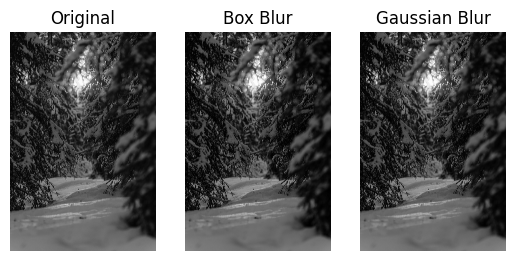

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image_test1.jpg", 0) # Changed 'image.jpg' to 'image_test1.jpg'

if img is None:
    print("Error: Could not load image. Please ensure 'image_test1.jpg' is in the current directory or provide the correct path.")
else:
    box = cv2.blur(img, (7,7))
    gauss = cv2.GaussianBlur(img, (7,7), 0)

    row = img.shape[0] // 2

    diff_original = np.abs(np.diff(img[row]))
    diff_box = np.abs(np.diff(box[row]))
    diff_gauss = np.abs(np.diff(gauss[row]))

    print("Original edge difference:", np.max(diff_original))
    print("Box edge difference:", np.max(diff_box))
    print("Gaussian edge difference:", np.max(diff_gauss))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(box, cmap="gray")
    plt.title("Box Blur")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(gauss, cmap="gray")
    plt.title("Gaussian Blur")
    plt.axis("off")

    plt.show()

# Challenge 6

In [ ]:
import cv2
import numpy as np
import time

img = cv2.imread("image_test1.jpg") # Changed 'image.jpg' to 'image_test1.jpg'

if img is None:
    print("Error: Could not load image. Please ensure 'image_test1.jpg' is in the current directory or provide the correct path.")
else:
    kernel = np.ones((3,3), np.float32)/9

    runs = 10
    t_filter2D = []
    t_gauss = []

    for _ in range(runs):
        start = time.time()
        cv2.filter2D(img, -1, kernel)
        t_filter2D.append(time.time() - start)

        start = time.time()
        cv2.GaussianBlur(img, (3,3), 0)
        t_gauss.append(time.time() - start)

    print("Average filter2D time:", np.mean(t_filter2D))
    print("Average GaussianBlur time:", np.mean(t_gauss))

Average filter2D time: 0.2856618404388428
Average GaussianBlur time: 0.26907198429107665


# Challenge 7

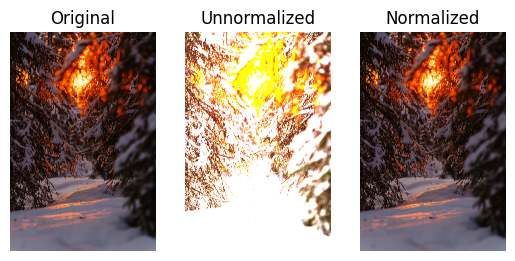

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image_test1.jpg") # Changed 'image.jpg' to 'image_test1.jpg'

if img is None:
    print("Error: Could not load image. Please ensure 'image_test1.jpg' is in the current directory or provide the correct path.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    kernel = np.array([[1,1,1],
                       [1,1,1],
                       [1,1,1]])

    img_bad = cv2.filter2D(img, -1, kernel)
    kernel_norm = kernel / kernel.sum()
    img_good = cv2.filter2D(img, -1, kernel_norm)

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(img_bad)
    plt.title("Unnormalized")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(img_good)
    plt.title("Normalized")
    plt.axis("off")

    plt.show()

# Challenge 8

In [ ]:
import cv2
import matplotlib.pyplot as plt

def apply_uniform(img, ksize):
    return cv2.blur(img, (ksize, ksize))

def apply_gaussian(img, ksize, sigma):
    return cv2.GaussianBlur(img, (ksize, ksize), sigma)

def show_images(original, filtered, title_filtered):
    plt.subplot(1,2,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(filtered)
    plt.title(title_filtered)
    plt.axis("off")

    plt.show()

img_path = input("Please enter the image path (e.g., image_test1.jpg): ")
img = cv2.imread(img_path)

if img is None:
    print(f"Error: Could not load image from '{img_path}'. Please ensure the file exists and the path is correct.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print("Filter:")
    print("1 - Uniform (box)")
    print("2 - Gaussian")
    choice = input("(1 or 2): ")

    ksize = int(input("Choose kernel size (odd numbers, for ex: 3,5,7): "))

    if choice == "1":
        filtered = apply_uniform(img, ksize)
        show_images(img, filtered, "Uniform Filter")
    elif choice == "2":
        sigma = float(input("Sigma for Gaussian (example 1.0, 5.0): "))
        filtered = apply_gaussian(img, ksize, sigma)
        show_images(img, filtered, f"Gaussian Filter (σ={sigma})")
    else:
        print("Wrong choice!")

Please enter the image path (e.g., image_test1.jpg): 3
Error: Could not load image from '3'. Please ensure the file exists and the path is correct.
